In [1]:
import numpy as np
import matplotlib.pyplot as plt

plt.style.use('bmh') 
colors = ["#3d5a80","#98c1d9","#e0fbfc","#ee6c4d","#293241"]

X = np.array([[0, 0],
              [0, 1],
              [1, 0],
              [1, 1]])

y = np.array([[0], 
              [1], 
              [1], 
              [0]])


In [91]:
# NN with one hidden layer and two hidden units
# First hidden layer: h1= g(W_1*X + b_1)
# final layer: y = W_2*h1 + b_2

layer_width = 3

# Hidden layer 1 (2 inputs, 2 nodes)
W_h1 = np.random.randn(2, layer_width)
b_h1 = np.zeros(layer_width)

# Output layer (10 inputs, 1 output)
W_o = np.random.randn(layer_width,1)
b_o = np.zeros(1)

In [49]:
def relu(x):
    return np.maximum(0, x)

def relu_gradient(z):
   return (z > 0).astype(float)

def forward_pass(x, W_h1, b_h1, W_o, b_o):
    z1 = np.dot(x, W_h1) + b_h1
    h1 = relu(z1)
    y_hat = np.dot(h1, W_o) + b_o
    return y_hat, h1, z1


def backward_pass(x, y_true, y_hat, h1, z1, W_o):
    # Output layer gradients
    gradient_y = y_hat - y_true
    dW_o = np.dot(h1.T, gradient_y)
    db_o = gradient_y[0]

    # Hidden layer gradients
    gradient_h1 = np.dot(gradient_y, W_o.T)
    gradient_z_h1 = gradient_h1 * relu_gradient(z1)
    dW_h1 = np.dot(x.T, gradient_z_h1)
    db_h1 = gradient_z_h1[0]

    return dW_h1, db_h1, dW_o, db_o

In [92]:
mse_log = []
learning_rate = 0.01

for iteration in range(1000):
    y_hats = np.array([])
    for idx in range(X.shape[0]):
        x = X[idx : idx + 1]
        y_true = y[idx : idx + 1]
    
        # 1. Forward Pass
        y_hat, h1, z1 = forward_pass(x, W_h1, b_h1, W_o, b_o)
        y_hats = np.append(y_hats, y_hat)
    
        # 2. Backward Pass
        dW_h1, db_h1, dW_o, db_o = backward_pass(x, y_true, y_hat, h1, z1, W_o)
    
        # 3. Parameter Updates
        W_o -= dW_o * learning_rate
        b_o -= db_o * learning_rate
        W_h1 -= dW_h1 * learning_rate
        b_h1 -= db_h1 * learning_rate

    mse = np.mean(np.square(y.T - y_hats)).round(5)
    mse_log.append(mse)



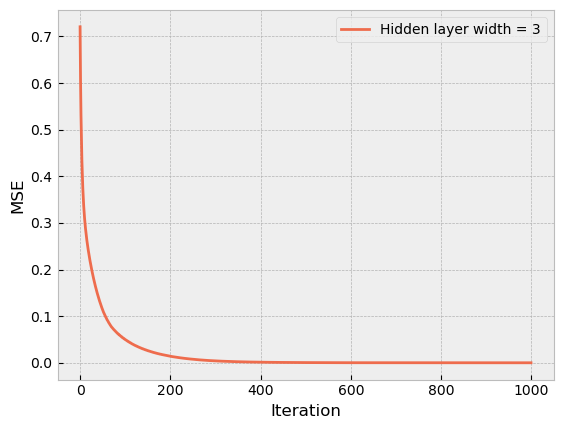

In [93]:
plt.plot([mse_log, c=colors[3], label="Hidden layer width = 3")
plt.xlabel('Iteration')
plt.ylabel('MSE')
plt.legend()
plt.savefig("plot.png")